In [6]:
import sys
import os
import PSSpy as pss
import numpy as np
from numpy import linalg as LA
from scipy.interpolate import interp1d
from scipy.signal import convolve2d
from astropy.io import fits 
from spectral_cube import SpectralCube
from astropy import units as u
import matplotlib.pyplot as plt
from matplotlib.colors import PowerNorm
from mpl_toolkits.axes_grid1 import make_axes_locatable
sys.path.append(os.getcwd()) # change the name of directory.
sys.path.append(os.path.abspath("Imfits"))
from imfits import Imfits


/Users/thchuang/Documents/GitHub/PSSmodel/Imfits/imfits/au.py:246: SyntaxWarning: invalid escape sequence '\m'
  cbar.set_label(r'$\mathrm{km\ s^{-1}}$')


In [10]:
ra_start = '04:31:38.217'
ra_end = '04:31:38.639'
dec_deg = 18 + 13/60 + 57.19/3600  # +31.21.38.180 => 31.3606 度
distance_pc = 147
n_pixels = 401

# arcsec_range, AU_per_pixel = pss.calc_ra_arcsec(ra_start, ra_end, dec_deg, distance_pc, n_pixels)

# print(f"RA arcsec range (rounded): {arcsec_range} arcsec")
# print(f"AU per pixel: {AU_per_pixel:.2f} AU/pixel")

In [11]:
# ----------- input -----------
f_cube = "HLTau_HCOp32.fits"
# f_mom0 = 
# f_mom1 = 

im_cube = Imfits(f_cube)

# im_mom0 = Imfits(f_mom0)
# im_mom1 = Imfits(f_mom1)


The third axis is  VRAD


In [12]:

cube = SpectralCube.read('HLTau_HCOp32.fits')

# Subcube and moment calculation
velocity_range = [-1.6, 15] * u.km / u.s  # Adjusted velocity range
subcube = cube.spectral_slab(velocity_range[0], velocity_range[1])
moment0 = subcube.moment(order=0).value
moment1 = subcube.moment(order=1).value
rms_mom0 = 1.018084744813e-1
rms_channel = 2.436712102076e-3
# mom0_3rms = np.ma.masked_where(moment0 < 3.5*rms_channel, moment0)
# mom1_3rms = np.ma.masked_where(moment0 < 3.5*rms_channel, moment1)

In [13]:
hdu_mom0 = fits.PrimaryHDU(data=moment0, header=im_cube.header)
hdu_mom0.writeto('HLTau_HCOp32_mom0.fits', overwrite=True)
hdu_mom1 = fits.PrimaryHDU(data=moment1, header=im_cube.header)
hdu_mom1.header['BUNIT'] = 'km/s'
hdu_mom1.writeto('HLTau_HCOp32_mom1.fits', overwrite=True)

In [14]:
find_streamcom = np.array([[201, 201], [196, 220], [207, 226], [226, 227], [251,227], [267, 207], [277, 185], [289, 161], [298, 139], [305, 94]]) - (201, 201)


In [15]:
# [[0, 0], [207, 226], [226, 227], [251,227], [267, 207], [277, 185], [289, 161], [298, 139], [305, 94]] - (196, 220)
find_r, find_theta = pss.spherical_coords(find_streamcom[:, 0], find_streamcom[:, 1])
find_streaml = interp1d(find_r, find_theta)
find_r

array([  0.        ,  19.6468827 ,  25.70992026,  36.06937759,
        56.35601121,  66.2721661 ,  77.66595136,  96.66436779,
       115.12167476, 149.21461054])

In [16]:
3 * rms_channel

0.0073101363062280005

In [17]:
cube_data = cube.filled_data[:].value
init_points = [(274, 196, 220), (274, 207, 226), (274, 226, 227), (274, 251, 227), (274, 267, 207), (274, 277, 185), (274, 289, 161), (274, 298, 139), (274, 305, 94)]
stream_mask = pss.grow_region(cube_data, init_points, rms_channel, sigma_thresh=3, max_iter=2000)


In [19]:
masked_cube = cube.with_mask(stream_mask)
str_moment0 = masked_cube.moment(order=0)

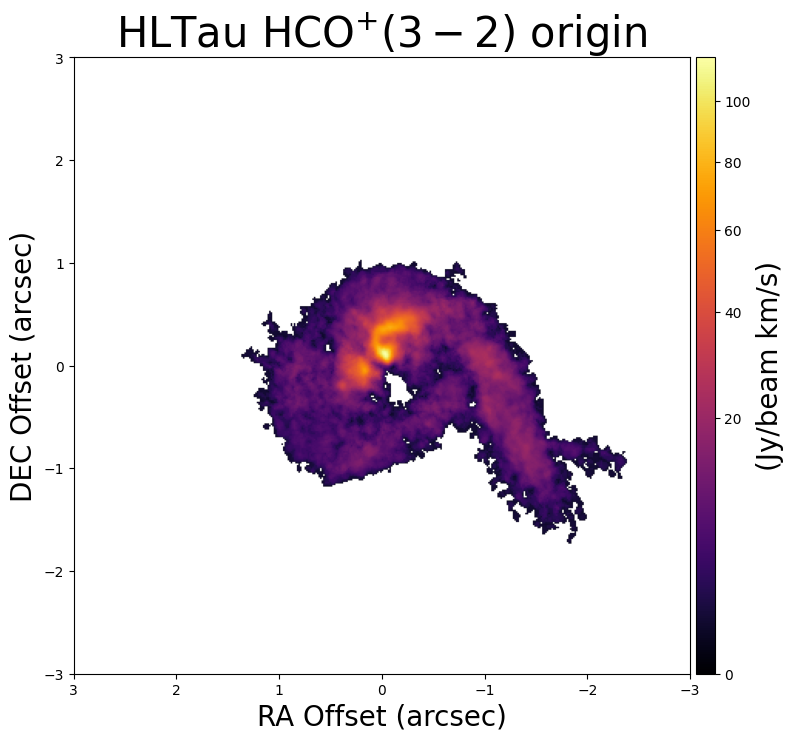

In [20]:
xmin, xmax = im_cube.xaxis[0]*3600., im_cube.xaxis[-1]*3600.
ymin, ymax = im_cube.yaxis[0]*3600., im_cube.yaxis[-1]*3600.
delx, dely = im_cube.delx*3600., im_cube.dely*3600.
extent = (xmin - 0.5*delx, xmax + 0.5*delx,
    ymin - 0.5*dely, ymax + 0.5*dely) # image extent

# plot, relative coordinate
# figure
fig = plt.figure(figsize=(8.27, 8.27))
ax  = fig.add_subplot(111)
# color
norm = PowerNorm(gamma=0.5, vmin=0)  # Adjust gamma for better visibility
imcolor = ax.imshow(str_moment0.value, origin='lower', cmap='inferno', extent=extent, norm=norm)
# color bar
divider = make_axes_locatable(ax)
cax     = divider.append_axes('right', size='3%', pad='1%')
cbar = fig.colorbar(imcolor, cax=cax)
cbar.set_label('(Jy/beam km/s)',fontsize=20)

# range
ax.set_xlim(3, -3)
ax.set_ylim(-3, 3)

# axis label
ax.set_title('HLTau '+r'$\rm HCO^{+} (3-2)$'+' origin',fontsize=30)
ax.set_xlabel('RA Offset (arcsec)',fontsize=20)
ax.set_ylabel('DEC Offset (arcsec)',fontsize=20)
plt.show()

In [21]:
def gaussian_kernel(size=5, sigma=1.0):
    """
    建立 2D Gaussian kernel
    size: 核心大小（應為奇數）
    sigma: 高斯標準差
    """
    ax = np.arange(-size // 2 + 1, size // 2 + 1)
    xx, yy = np.meshgrid(ax, ax)
    rr = np.sqrt(xx**2 + yy**2)
    
    # 計算高斯核
    kernel = np.exp(-(xx**2 + yy**2) / (2 * sigma**2))

    # 建立圓形 mask（只保留距離中心在 size//2 內的）
    radius = size / 2
    circular_mask = rr <= radius
    kernel *= circular_mask  # 將外圓區域設為0
    
    return kernel / np.sum(kernel)

# 建立高斯 kernel
kernel = gaussian_kernel(size=5, sigma=1.0)
print("Gaussian kernel:\n", kernel)
smoothed_data = convolve2d(str_moment0.value, kernel, fillvalue=0)

Gaussian kernel:
 [[0.         0.01346613 0.0222019  0.01346613 0.        ]
 [0.01346613 0.06035103 0.09950202 0.06035103 0.01346613]
 [0.0222019  0.09950202 0.1640511  0.09950202 0.0222019 ]
 [0.01346613 0.06035103 0.09950202 0.06035103 0.01346613]
 [0.         0.01346613 0.0222019  0.01346613 0.        ]]


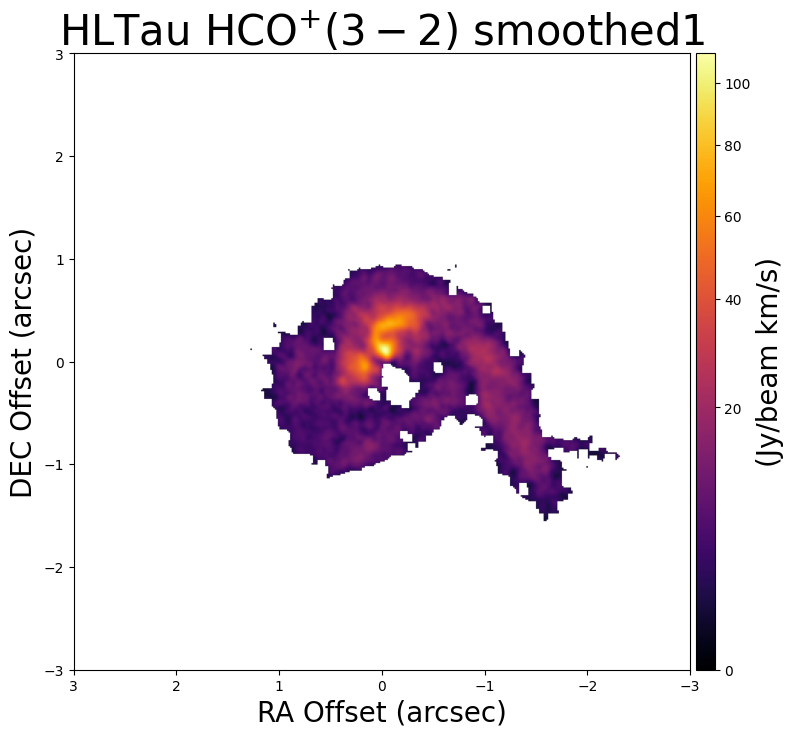

In [22]:
xmin, xmax = im_cube.xaxis[0]*3600., im_cube.xaxis[-1]*3600.
ymin, ymax = im_cube.yaxis[0]*3600., im_cube.yaxis[-1]*3600.
delx, dely = im_cube.delx*3600., im_cube.dely*3600.
extent = (xmin - 0.5*delx, xmax + 0.5*delx,
    ymin - 0.5*dely, ymax + 0.5*dely) # image extent

# plot, relative coordinate
# figure
fig = plt.figure(figsize=(8.27, 8.27))
ax  = fig.add_subplot(111)
# color
norm = PowerNorm(gamma=0.5, vmin=0)  # Adjust gamma for better visibility
imcolor = ax.imshow(smoothed_data, origin='lower', cmap='inferno', extent=extent, norm=norm)
# color barˋ
divider = make_axes_locatable(ax)
cax     = divider.append_axes('right', size='3%', pad='1%')
cbar = fig.colorbar(imcolor, cax=cax)
cbar.set_label('(Jy/beam km/s)',fontsize=20)

# range
ax.set_xlim(3, -3)
ax.set_ylim(-3, 3)

# axis label
ax.set_title('HLTau '+r'$\rm HCO^{+} (3-2)$'+' smoothed1',fontsize=30)
ax.set_xlabel('RA Offset (arcsec)',fontsize=20)
ax.set_ylabel('DEC Offset (arcsec)',fontsize=20)
plt.show()

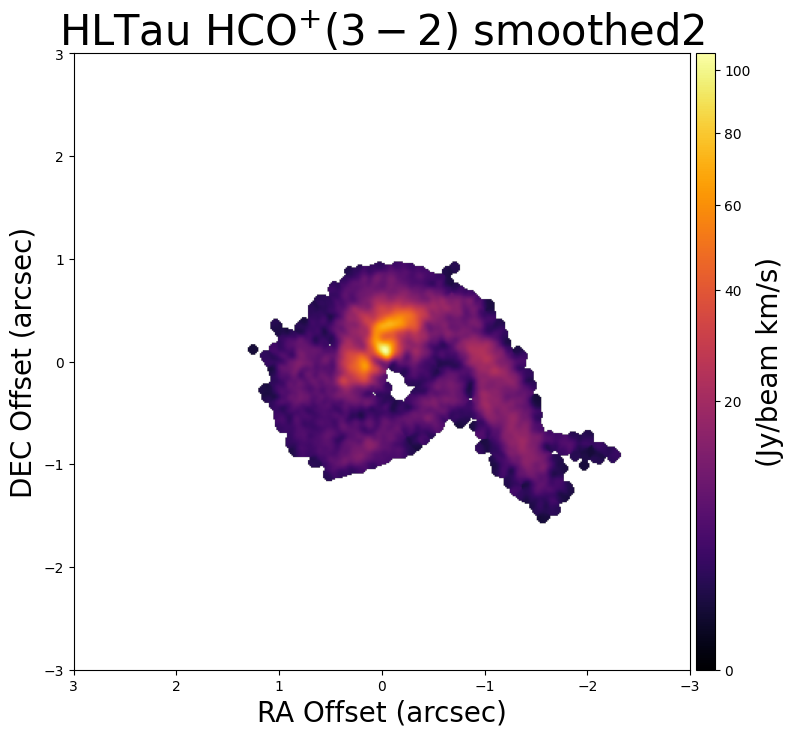

In [23]:
def smooth_with_nan(data, sigma=3):
    # 建立 NaN mask
    nan_mask = np.isnan(data)

    # 將 NaN 設為 0 計算平滑（但不會用這些值）
    data_zero = np.nan_to_num(data, nan=0.0)
    
    kernel = gaussian_kernel(size=sigma, sigma=1.0)

    # 平滑原始值和 mask（加權平滑）
    smoothed_data = convolve2d(data_zero, kernel, fillvalue=0)
    smooth_mask = convolve2d(~nan_mask, kernel, fillvalue=0)

    # 防止除以零
    smooth_mask[smooth_mask == 0] = np.nan

    # 回傳補洞後的 smoothed 圖
    return smoothed_data / smooth_mask


# 平滑處理
smoothed = smooth_with_nan(smoothed_data, sigma=7)

xmin, xmax = im_cube.xaxis[0]*3600., im_cube.xaxis[-1]*3600.
ymin, ymax = im_cube.yaxis[0]*3600., im_cube.yaxis[-1]*3600.
delx, dely = im_cube.delx*3600., im_cube.dely*3600.
extent = (xmin - 0.5*delx, xmax + 0.5*delx,
    ymin - 0.5*dely, ymax + 0.5*dely) # image extent

# plot, relative coordinate
# figure
fig = plt.figure(figsize=(8.27, 8.27))
ax  = fig.add_subplot(111)
# color
norm = PowerNorm(gamma=0.5, vmin=0)  # Adjust gamma for better visibility
imcolor = ax.imshow(smoothed, origin='lower', cmap='inferno', extent=extent, norm=norm)
# color barˋ
divider = make_axes_locatable(ax)
cax     = divider.append_axes('right', size='3%', pad='1%')
cbar = fig.colorbar(imcolor, cax=cax)
cbar.set_label('(Jy/beam km/s)',fontsize=20)

# range
ax.set_xlim(3, -3)
ax.set_ylim(-3, 3)

# axis label
ax.set_title('HLTau '+r'$\rm HCO^{+} (3-2)$'+' smoothed2',fontsize=30)
ax.set_xlabel('RA Offset (arcsec)',fontsize=20)
ax.set_ylabel('DEC Offset (arcsec)',fontsize=20)
plt.show()


In [24]:
x = np.arange(401) - 201 
z = np.arange(401) - 201
xx, zz = np.meshgrid(x, z)
r, theta = pss.spherical_coords(xx, zz)

N_elements = 11
pars = np.linspace(10,155,N_elements+1)  # Define distance ranges
xmeans = np.zeros(N_elements)
zmeans = np.zeros(N_elements)
xzstd = np.zeros(N_elements)
x_means = np.zeros(N_elements)
z_means = np.zeros(N_elements)
v_means = np.zeros(N_elements)
pcstds = np.zeros((2,N_elements))  # intialize "empty" array
x_array_list = []
z_array_list = []
v_array_list = []
weights_list = []

for i in range(N_elements):
    dinds = (r>pars[i]) & (r<=pars[i+1]) & np.isfinite(moment0)  # Identify points in given distance range
    r_streaml = (pars[i] + pars[i+1]) / 2
    # print(r_streaml)
    theta0 = find_streaml(r_streaml)
    weight_theta = (xx * np.cos(theta0) + zz * np.sin(theta0)) / r
    weight_theta[weight_theta < 0.9] = 0
    xmeans[i] = np.average(xx[dinds],weights=moment0[dinds] * weight_theta[dinds])  # Add means
    zmeans[i] = np.average(zz[dinds],weights=moment0[dinds] * weight_theta[dinds])  # Add means    
    xzstd[i] = np.sqrt(np.average((xx[dinds] - xmeans[i]) ** 2 + (zz[dinds] - zmeans[i]) ** 2, weights=moment0[dinds] * weight_theta[dinds]))  # Add std

r_means, theta_means = pss.spherical_coords(xmeans,zmeans)

theta_r = interp1d(r_means, theta_means, fill_value=(theta_means[0], theta_means[-1]), bounds_error=False) #
std_r = interp1d(r_means, xzstd, fill_value=(xzstd[0], xzstd[-1]), bounds_error=False)

mom1_vel = np.ma.masked_invalid(moment1.data)  # Mask invalid values in moment1 data

for i in range(N_elements):
    r_ref = (pars[i]+ pars[i+1]) / 2
    theta_ref = theta_r(r_ref)
    std_ref = std_r(r_ref) / r_ref
    
    delta_theta = np.pi-np.abs(np.pi-np.abs(theta-theta_ref))
    weights = moment0 * pss.gaussian(delta_theta, 0, std_ref)

    dinds = (r>pars[i]) & (r<=pars[i+1])  # Identify points in given distance range
    dinds_v = (r>pars[i]) & (r<=pars[i+1]) & np.isfinite(moment1)
    
    # 存儲每次迴圈的值
    x_array_list.append(xx[dinds])
    z_array_list.append(zz[dinds])
    v_array_list.append(mom1_vel[dinds])
    weights_list.append(weights[dinds]/np.max(weights[dinds]))
    
    x_means[i] = np.average(xx[dinds],weights=weights[dinds])  # Add means  
    z_means[i] = np.average(zz[dinds],weights=weights[dinds])  # Add means
    v_means[i] = np.average(mom1_vel[dinds_v], weights=weights[dinds_v]) #
    # v_means[i] = np.sum(mom1_vel[dinds] * weights[dinds]) / np.sum(weights[dinds])
    
r_means, theta_means = pss.spherical_coords(x_means,z_means)

x_array = np.array(x_array_list, dtype=object)
z_array = np.array(z_array_list, dtype=object)
v_array = np.array(v_array_list, dtype=object)
weights_array = np.array(weights_list, dtype=object)


/var/folders/9m/kvnj0x452kx_fptbkd6sbbxm0000gn/T/ipykernel_63222/1751516001.py:25: RuntimeWarning: invalid value encountered in divide
  weight_theta = (xx * np.cos(theta0) + zz * np.sin(theta0)) / r
/var/folders/9m/kvnj0x452kx_fptbkd6sbbxm0000gn/T/ipykernel_63222/1751516001.py:29: RuntimeWarning: invalid value encountered in sqrt
  xzstd[i] = np.sqrt(np.average((xx[dinds] - xmeans[i]) ** 2 + (zz[dinds] - zmeans[i]) ** 2, weights=moment0[dinds] * weight_theta[dinds]))  # Add std


In [25]:
np.rad2deg(0.2)

np.float64(11.459155902616466)

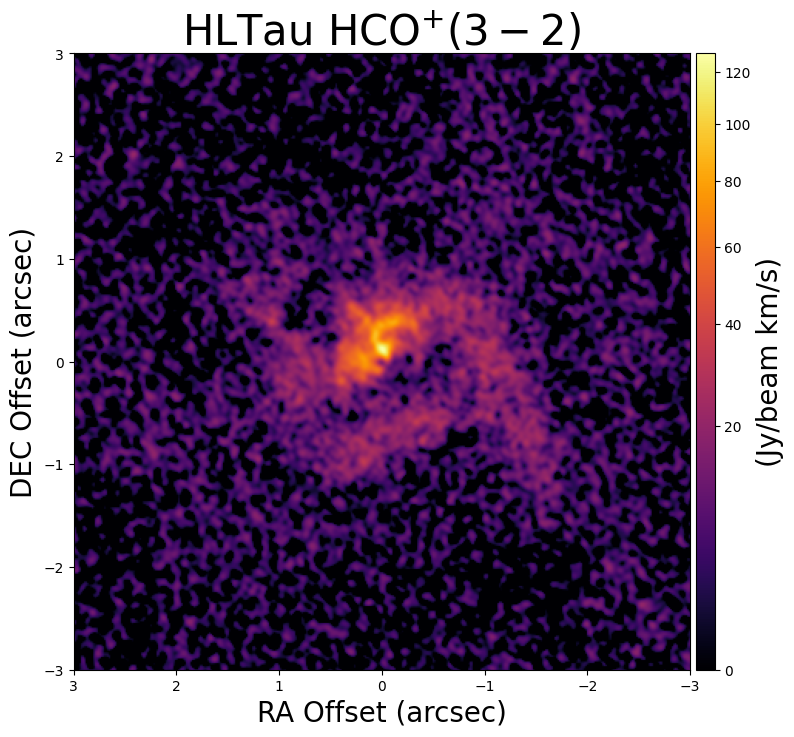

In [26]:
cmap       = 'inferno'  # color
# axes in arcsec
xmin, xmax = im_cube.xaxis[0]*3600., im_cube.xaxis[-1]*3600.
ymin, ymax = im_cube.yaxis[0]*3600., im_cube.yaxis[-1]*3600.
delx, dely = im_cube.delx*3600., im_cube.dely*3600.
extent = (xmin - 0.5*delx, xmax + 0.5*delx,
    ymin - 0.5*dely, ymax + 0.5*dely) # image extent

# plot, relative coordinate
# figure
fig = plt.figure(figsize=(8.27, 8.27))
ax  = fig.add_subplot(111)
# color
norm = PowerNorm(gamma=0.5, vmin=0)
imcolor = ax.imshow(moment0, origin='lower',
    cmap=cmap, extent=extent, norm=norm)
# color bar
divider = make_axes_locatable(ax)
cax     = divider.append_axes('right', size='3%', pad='1%')
cbar = fig.colorbar(imcolor, cax=cax)
cbar.set_label('(Jy/beam km/s)',fontsize=20)

# range
ax.set_xlim(3, -3)
ax.set_ylim(-3, 3)

# axis label
ax.set_title('HLTau '+r'$\rm HCO^{+} (3-2)$',fontsize=30)
ax.set_xlabel('RA Offset (arcsec)',fontsize=20)
ax.set_ylabel('DEC Offset (arcsec)',fontsize=20)
plt.show()

NameError: name 'arcsec_range' is not defined

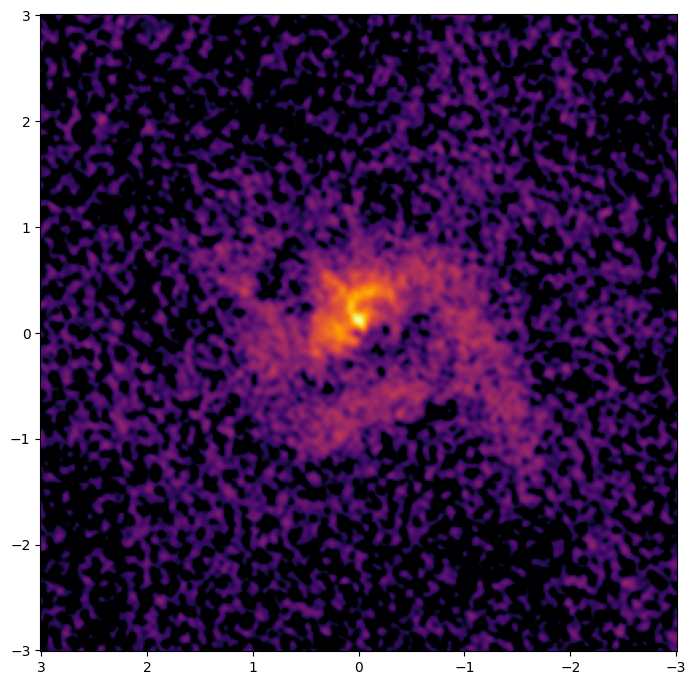

In [27]:
# ----------- input -----------
# parameters for plot
# moment I map in color
cmap       = 'inferno'  # color
# vmin, vmax = -1, 1   # color range

# ---------- ma"in -------------
# read fits file
#  see https://github.com/jinshisai/Imfits/blob/main/imfits/_imfits.py
#   for how to read fits header
# im_mom0 = Imfits(f_mom0)

# # by yorself
# # data
# data_mom0 = im_mom0.data
# data_mom0 = np.sign(data_mom0)
# axes in arcsec
xmin, xmax = im_cube.xaxis[0]*3600., im_cube.xaxis[-1]*3600.
ymin, ymax = im_cube.yaxis[0]*3600., im_cube.yaxis[-1]*3600.
delx, dely = im_cube.delx*3600., im_cube.dely*3600.
extent = (xmin - 0.5*delx, xmax + 0.5*delx,
    ymin - 0.5*dely, ymax + 0.5*dely) # image extent

# plot, relative coordinate
# figure
fig = plt.figure(figsize=(8.27, 8.27))
ax  = fig.add_subplot(111)
# color
norm = PowerNorm(gamma=0.5, vmin=0)
imcolor = ax.imshow(moment0, origin='lower',
    cmap=cmap, extent=extent, norm=norm)
# plt.plot(- xmeans * xmax / 201, zmeans * ymax / 201)
ax.plot( - x_means * arcsec_range / n_pixels + delx, z_means * arcsec_range / n_pixels + dely, 'w')
# ax.scatter( - find_streamcom[:, 0] * arcsec_range / n_pixels + delx, find_streamcom[:, 1] * arcsec_range / n_pixels + dely, c='r', s=10, marker='+')
num_element = 1
# weights_im = ax.scatter( - x_array[num_element] * arcsec_range / n_pixels, z_array[num_element] * arcsec_range / n_pixels, c=weights_array[num_element], s=1, cmap='YlGn_r')

# ax.scatter(0, 0, c='r', s=100, marker='+')

# color bar
divider = make_axes_locatable(ax)
cax     = divider.append_axes('right', size='3%', pad='1%')
cbar = fig.colorbar(imcolor, cax=cax)
cbar.set_label('(Jy/beam km/s)',fontsize=20)

# divider = make_axes_locatable(ax)
# cax     = divider.append_axes('right', size='3%', pad='1%')
# cbar = fig.colorbar(weights_im, cax=cax)
# cbar.set_label('weight value',fontsize=20, loc='center')

# range
ax.set_xlim(3, -3)
ax.set_ylim(-3, 3)

# axis label
ax.set_title('HLTau '+r'$\rm HCO^{+} (3-2)$',fontsize=30)
ax.set_xlabel('RA Offset (arcsec)',fontsize=20)
ax.set_ylabel('DEC Offset (arcsec)',fontsize=20)

# text_pos_x, text_pos_y = 35, -35
# scale_length = 3000 #AU
# scale_range_x = [text_pos_x, text_pos_x - scale_length / AU_per_pixel * arcsec_range / n_pixels]
# scale_range_y = [text_pos_y - 0.2, text_pos_y - 0.2]
# ax.text(text_pos_x - 5, text_pos_y, str(scale_length)+' AU', ha = 'center', va = 'bottom', fontsize=16, family = 'times', color='w')
# ax.plot(scale_range_x, scale_range_y,color='w',lw=3)
# ax.quiver(2,-2,-1,-1, color='lightgrey', scale=12)


# # --- 橢圓參數設定 ---
# semi_major_AU = 1000               # 長軸長度 (AU)
# semi_major_arcsec = semi_major_AU / AU_per_pixel * arcsec_range / n_pixels# 長軸長度 (arcsec)
# inclination_deg = 57              # 傾角 i (0° face-on, 90° edge-on)
# pa_deg_disk = 45                       # 位置角 PA，從北到東 (counter-clockwise from y-axis)

# # 計算短軸長度
# semi_minor_arcsec = semi_major_arcsec * np.cos(np.deg2rad(inclination_deg))

# # 橢圓中心位置 (以圖的中心為例)
# center_x = 0     # RA offset
# center_y = 0     # DEC offset

# # 加入橢圓
# ellipse = Ellipse(
#     xy=(center_x, center_y),
#     width=2*semi_major_arcsec,
#     height=2*semi_minor_arcsec,
#     angle=pa_deg_disk,
#     edgecolor='cyan',
#     facecolor='none',
#     lw=2,
#     linestyle='--',
#     zorder=5
# )
# ax.add_patch(ellipse)

# save/show
folder_path = "image"
outname  = 'HLTau'  # outputname
# plt.savefig(os.path.join(folder_path, outname+'.png'), dpi=300, bbox_inches='tight')
plt.show()
